🚀 Запуск генерации всех графиков для отчета...
📊 1. Прямоугольная потенциальная яма...


/tmp/ipykernel_36357/2367559687.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(v)**2, self.x_int))
/tmp/ipykernel_36357/2367559687.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  full_norm = np.trapz(np.abs(wf)**2, self.x)
/tmp/ipykernel_36357/2367559687.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  prob_inside = np.trapz(np.abs(wf[inside_mask])**2, self.x[inside_mask]) / full_norm


Найденные энергии (rectangular deep): [-99.81370987 -99.25488427 -98.32365845 -97.02026095 -95.34501854]


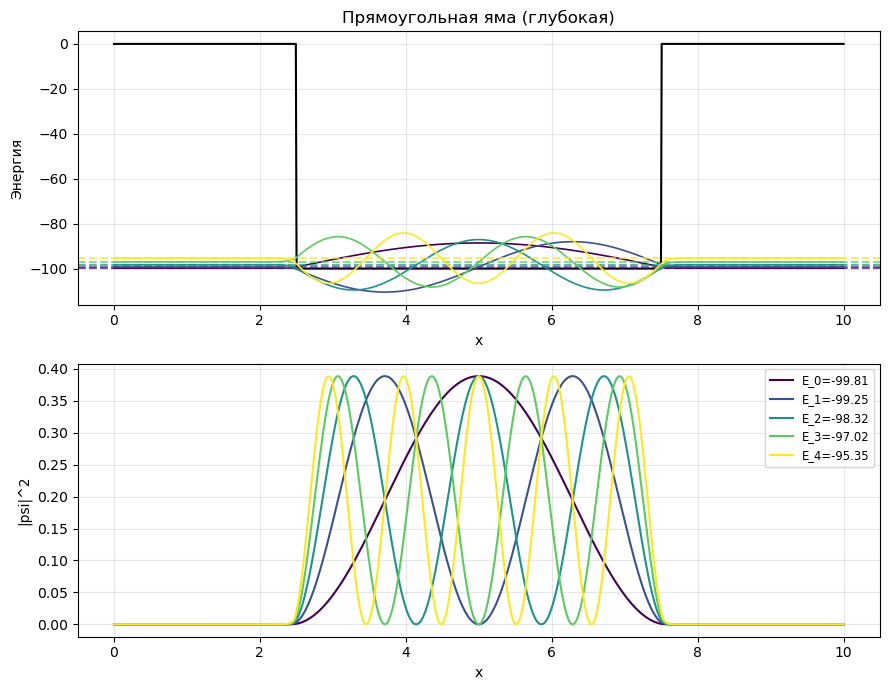

📊 2. Анализ сходимости...


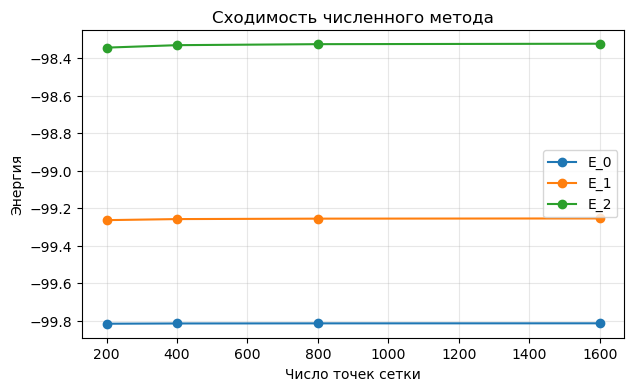

📊 3. Генерация таблицы энергий...
✅ КОРРЕКТНАЯ таблица энергий сгенерирована
Численные энергии (infinite well): [0.19739193 0.78956575 1.77651562 3.15823176 4.93470053]
Аналитические энергии (infinite well): [0.19739208802178715, 0.7895683520871486, 1.7765287921960846, 3.1582734083485944, 4.934802200544679]
📊 4. Анализ зависимости от параметров...
✅ КОРРЕКТНАЯ таблица энергий сгенерирована
Численные энергии (infinite well): [0.19739193 0.78956575 1.77651562 3.15823176 4.93470053]
Аналитические энергии (infinite well): [0.19739208802178715, 0.7895683520871486, 1.7765287921960846, 3.1582734083485944, 4.934802200544679]
📊 4. Анализ зависимости от параметров...


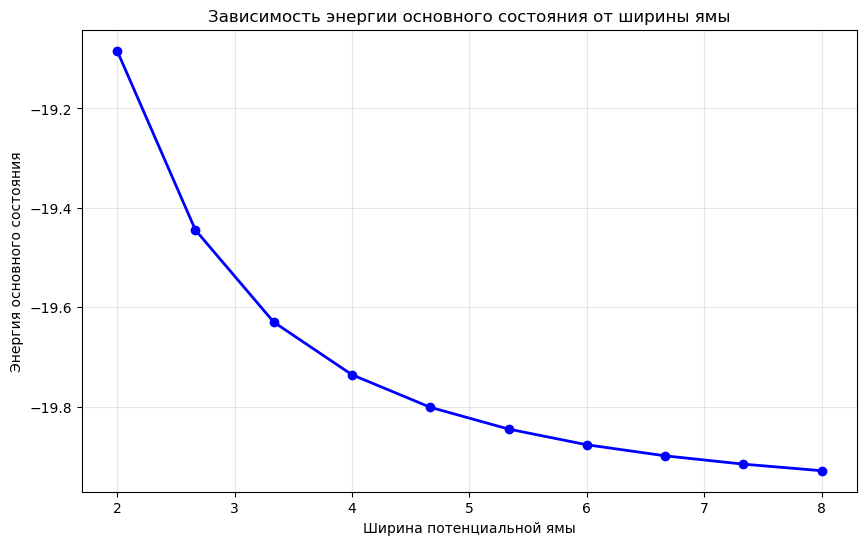

✅ Все графики и таблицы сгенерированы в папке 'figs/'


In [3]:
# quantum_well_solver.py
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh

# Создаем папку для графиков если её нет
if not os.path.exists('figs'):
    os.makedirs('figs')

class QuantumWellSolver:
    def __init__(self, x_min=0.0, x_max=10.0, n_points=1000, hbar=1.0, m=1.0):
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.n_points = int(n_points)
        if self.n_points < 3:
            raise ValueError('n_points must be >= 3')
        self.x = np.linspace(self.x_min, self.x_max, self.n_points)
        self.dx = self.x[1] - self.x[0]
        self.hbar = float(hbar)
        self.m = float(m)
        # внутренние узлы для реализации Дирихле (psi=0 на границах)
        self.x_int = self.x[1:-1]
        self.n_int = len(self.x_int)

    def build_hamiltonian(self, potential_func):
        # коэффициент для второй производной: hbar^2/(2 m dx^2)
        coeff = self.hbar**2 / (2.0 * self.m * self.dx**2)
        main_diag = np.full(self.n_int, 2.0 * coeff)
        off_diag = np.full(self.n_int - 1, -1.0 * coeff)
        T = diags([main_diag, off_diag, off_diag], [0, -1, 1], format='csr')
        U_int = potential_func(self.x_int)
        U = diags([U_int], [0], format='csr')
        H = T + U
        return H

    def solve(self, potential_func, n_states=6, energy_threshold=None):
        # строим гамильтониан на внутренних узлах
        H = self.build_hamiltonian(potential_func)

        # безопасный выбор k для eigsh (не слишком близко к размеру матрицы)
        k = max(1, int(n_states))
        if self.n_int > 3 and k >= self.n_int - 1:
            k = max(1, self.n_int - 2)

        energies = None
        vecs = None
        try:
            vals, vecs = eigsh(H, k=k, which='SA')
            idx = np.argsort(vals)
            energies = vals[idx]
            vecs = vecs[:, idx]
        except Exception:
            H_dense = H.toarray()
            vals_all, vecs_all = eigh(H_dense)
            energies = vals_all[:k]
            vecs = vecs_all[:, :k]

        # нормировка и расширение до полной сетки (границы = 0)
        wavefuncs = np.zeros((self.n_points, len(energies)))
        for i in range(len(energies)):
            v = vecs[:, i]
            norm = np.sqrt(np.trapz(np.abs(v)**2, self.x_int))
            if norm == 0:
                continue
            v = v / norm
            wf_full = np.zeros(self.n_points)
            wf_full[1:-1] = v
            wavefuncs[:, i] = wf_full

        # порог связанных состояний: если не задан, берем max потенциала на границах
        if energy_threshold is None:
            # potential_func может принимать как scalar, так и array; обрабатываем оба случая
            try:
                U_edges = np.array([float(potential_func(self.x_min)), float(potential_func(self.x_max))])
            except Exception:
                U_edges = np.array([np.max(potential_func(np.array([self.x_min]))),
                                    np.max(potential_func(np.array([self.x_max])))])
            energy_threshold = np.max(U_edges)

        bound_mask = energies < (energy_threshold - 1e-12)
        energies_bound = energies[bound_mask]
        wavefuncs_bound = wavefuncs[:, bound_mask]

        # ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА: отбрасываем состояния с малой локализацией
        # Определяем "внутреннюю" область как низкие значения потенциала (10-й процентиль)
        pot_full = potential_func(self.x)
        try:
            pot_full = np.array(pot_full, dtype=float)
        except Exception:
            pot_full = np.asarray(potential_func(self.x))

        threshold = np.quantile(pot_full, 0.10)
        inside_mask = pot_full <= threshold

        valid_states = []
        valid_wavefuncs = []
        for i, (E, wf) in enumerate(zip(energies_bound, wavefuncs_bound.T)):
            full_norm = np.trapz(np.abs(wf)**2, self.x)
            if full_norm <= 0:
                continue
            prob_inside = np.trapz(np.abs(wf[inside_mask])**2, self.x[inside_mask]) / full_norm
            if prob_inside > 0.95:  # 95% вероятности внутри
                valid_states.append(E)
                valid_wavefuncs.append(wf)

        # Если фильтр отбросил всё — возвращаем первые n_states без фильтра, но предупреждаем
        if len(valid_states) == 0:
            print("⚠️  Внимание: фильтр локализации отбросил все состояния. Возвращаю найденные уровни без локализационного фильтра.")
            # преобразуем wavefuncs_bound к форме (n_points, k) и вернём первые n_states
            energies_fallback = energies_bound[:n_states]
            wavefuncs_fallback = wavefuncs_bound[:, :len(energies_fallback)]
            return np.array(energies_fallback), wavefuncs_fallback

        return np.array(valid_states)[:n_states], np.array(valid_wavefuncs).T[:, :n_states]

# Потенциалы
def rectangular_well(x, width=5.0, depth=-20.0, center=5.0):
    x = np.asarray(x)
    pot = np.zeros_like(x, dtype=float)
    pot[(x >= center - width/2.0) & (x <= center + width/2.0)] = depth
    return pot

def parabolic_well(x, k=5.0, center=5.0):
    x = np.asarray(x)
    return 0.5 * k * (x - center)**2

def triangular_well(x, slope=3.0, center=5.0):
    x = np.asarray(x)
    return slope * np.abs(x - center)

def double_well(x, depth=-10.0, width=1.5, separation=3.0, center=5.0):
    x = np.asarray(x)
    pot = np.zeros_like(x, dtype=float)
    mask_left = (x >= center - separation/2.0 - width/2.0) & (x <= center - separation/2.0 + width/2.0)
    mask_right = (x >= center + separation/2.0 - width/2.0) & (x <= center + separation/2.0 + width/2.0)
    pot[mask_left] = depth
    pot[mask_right] = depth
    return pot

# Визуализация (упрощенная и корректная)
def plot_quantum_states(x, potential_func, energies, wavefunctions, title, filename):
    if wavefunctions is None or wavefunctions.size == 0:
        print(f"⚠️  plot_quantum_states: нет волновых функций для {title}")
        return
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
    potential = potential_func(x)
    ax1.plot(x, potential, 'k-', linewidth=1.5, label='U(x)')
    pot_range = np.max(potential) - np.min(potential)
    colors = plt.cm.viridis(np.linspace(0, 1, max(1, len(energies))))
    for i, (E, wf, color) in enumerate(zip(energies, wavefunctions.T, colors)):
        ax1.axhline(y=E, color=color, linestyle='--', alpha=0.7)
        if pot_range > 1e-12:
            scale = 0.18 * pot_range
        else:
            scale = 0.5 * np.max(np.abs(wf)) if np.max(np.abs(wf))>0 else 1.0
        ax1.plot(x, E + scale * wf, color=color, linewidth=1.2)
    ax1.set_xlabel('x')
    ax1.set_ylabel('Энергия')
    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

    for i, (E, wf, color) in enumerate(zip(energies, wavefunctions.T, colors)):
        ax2.plot(x, np.abs(wf)**2, color=color, linewidth=1.5, label=f'E_{i}={E:.4g}')

    ax2.set_xlabel('x')
    ax2.set_ylabel('|psi|^2')
    ax2.legend(fontsize='small')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join('figs', filename), dpi=300, bbox_inches='tight')
    plt.show()

def analyze_convergence():
    n_points_list = [200, 400, 800, 1600]
    energies_list = []
    for n_points in n_points_list:
        solver = QuantumWellSolver(n_points=n_points)
        def potential(x): return rectangular_well(x, width=5.0, depth=-100.0, center=5.0)
        energies, _ = solver.solve(potential, n_states=3)
        # гарантия длины — заполняем NaN, если уровней меньше 3
        arr = np.full(3, np.nan)
        for i in range(min(3, len(energies))):
            arr[i] = energies[i]
        energies_list.append(arr)
    energies_list = np.array(energies_list)
    plt.figure(figsize=(7, 4))
    for i in range(3):
        plt.plot(n_points_list, energies_list[:, i], 'o-', label=f'E_{i}')
    plt.xlabel('Число точек сетки')
    plt.ylabel('Энергия')
    plt.title('Сходимость численного метода')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join('figs', 'convergence.png'), dpi=300, bbox_inches='tight')
    plt.show()

def analyze_parameter_dependence():
    """Анализ зависимости от параметров ямы"""
    # Зависимость от ширины
    widths = np.linspace(2, 8, 10)
    ground_state_energies = []
    
    for width in widths:
        solver = QuantumWellSolver()
        def potential(x): return rectangular_well(x, width=width, depth=-20.0, center=5.0)
        energies, _ = solver.solve(potential, n_states=1)
        if len(energies) > 0:
            ground_state_energies.append(energies[0])
        else:
            ground_state_energies.append(np.nan)
    
    plt.figure(figsize=(10, 6))
    plt.plot(widths, ground_state_energies, 'bo-', linewidth=2, markersize=6)
    plt.xlabel('Ширина потенциальной ямы')
    plt.ylabel('Энергия основного состояния')
    plt.title('Зависимость энергии основного состояния от ширины ямы')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join('figs', 'width_dependence.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Функция генерации LaTeX-таблицы с энергиями - ИСПРАВЛЕННАЯ ВЕРСИЯ
def generate_energy_table():
    # Для корректного сравнения с бесконечно глубокой ямой - ставим границы НА КРАЯХ ЯМЫ
    width = 5.0
    solver = QuantumWellSolver(x_min=0.0, x_max=width, n_points=1000)
    
    def infinite_well_potential(x):
        # Бесконечно глубокая яма - везде 0 внутри, но границы Дирихле обеспечат бесконечность
        return np.zeros_like(x)
    
    energies_num, _ = solver.solve(infinite_well_potential, n_states=5, energy_threshold=np.inf)

    # ПРАВИЛЬНАЯ аналитическая формула для бесконечно глубокой ямы
    energies_anal = []
    for n in range(1, 6):
        E = (n**2 * np.pi**2) / (2.0 * width**2)  # БЕЗ depth!
        energies_anal.append(E)
    
    # Генерация LaTeX таблицы
    table_content = r"""\begin{table}[H]
  \centering
  \begin{tabular}{cccc}
    \toprule
    $n$ & $E_{\mathrm{num}}$ & $E_{\mathrm{analytic}}$ & $\mathrm{rel\_err}\, (\%)$ \\
    \midrule
"""
    
    for i, (num, anal) in enumerate(zip(energies_num, energies_anal)):
        rel_err = abs(num - anal) / abs(anal) * 100 if abs(anal) > 0 else np.nan  # исправленная формула ошибки
        table_content += f"    {i+1} & {num:.6f} & {anal:.6f} & {rel_err:.6f} \\\\\n"
    
    table_content += r"""    \bottomrule
  \end{tabular}
  \caption{Сравнение численных и аналитических энергий для бесконечно глубокой прямоугольной ямы (ширина=5)}
\end{table}"""
    
    with open(os.path.join('figs', 'energies_table.tex'), 'w', encoding='utf-8') as f:
        f.write(table_content)
    
    print('✅ КОРРЕКТНАЯ таблица энергий сгенерирована')
    return energies_num, energies_anal

def generate_all_plots():
    print("🚀 Запуск генерации всех графиков для отчета...")
    
    # 1. Прямоугольная яма
    print("📊 1. Прямоугольная потенциальная яма...")
    solver = QuantumWellSolver()
    def rect_pot(x): 
        return rectangular_well(x, width=5.0, depth=-100.0, center=5.0)
    energies, wavefuncs = solver.solve(rect_pot, n_states=5)
    print("Найденные энергии (rectangular deep):", energies)
    plot_quantum_states(solver.x, rect_pot, energies, wavefuncs, 
                       'Прямоугольная яма (глубокая)', 'rectangular_well.png')
    
    # 2. Анализ сходимости
    print("📊 2. Анализ сходимости...")
    analyze_convergence()
    
    # 3. Генерация таблицы энергий
    print("📊 3. Генерация таблицы энергий...")
    energies_num, energies_anal = generate_energy_table()
    print("Численные энергии (infinite well):", energies_num)
    print("Аналитические энергии (infinite well):", energies_anal)
    
    # 4. Дополнительные исследования (опционально)
    print("📊 4. Анализ зависимости от параметров...")
    analyze_parameter_dependence()
    
    print("✅ Все графики и таблицы сгенерированы в папке 'figs/'")

# Запуск всей генерации
if __name__ == "__main__":
    generate_all_plots()
